# Updated preprocessing


Load Doppler and Label.

Reorder Doppler to frames-first shape (N, 1, H, W) 0
optionally apply log10
Align image/label length with hf.mismatch(...) (trim to shortest)
Pad/crop frames to square target size (TARGET_SIZE=112).
optionally Load or create an ROI mask (roi_<file_idx>.npy). (similar to how its implemented in code\1_preprocessing\1_processing.ipynb, new boolean roi_on (true = create/load roi mask))

Run PCA denoising (hf.pca_denoise).

Zero values outside ROI. (if roi_on is true)

Optional temporal high-pass filter (HIGH_PASS == 'hp'; currently set to nohp, so off).
Percentile clip (BOTTOM=1, TOP=99).
ROI z-score normalization (hf.normalize_cbv_in_roi(..., 'zscore')). or just zscore and mean_divide if roi_on = false ( normalize as per code\1_preprocessing\1_processing.ipynb)
save nrmalized and preprocessed frames:
- files per normalization mode
- if highpass filter applied, labeled with _hp at the end


## Imports

In [2]:
import sys
from pathlib import Path

import yaml

# Locate repo root (same style as EDA notebooks)
repo_root = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "config" / "config.yml").exists()
)

# Add code directory to import path
code_dir = repo_root / "code"
if str(code_dir) not in sys.path:
    sys.path.insert(0, str(code_dir))

# Load config
config_path = repo_root / "config" / "config.yml"
config = yaml.safe_load(config_path.read_text(encoding="utf-8"))

# Core paths + subjects
deriv_root = repo_root / config["paths"]["preprocessing"]
source_root = repo_root / config["paths"]["sourcedata"]
subjects = config["subjects"]["all"]
sample_subject = config["subjects"]["default"]

In [3]:
import os
import importlib

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from utils.preprocessing.geometry import reorient_baseline_sessions
from utils.preprocessing.io import summarize_npz_collection
from utils import helper_functions as hf
from utils.preprocessing import standardization as stdz
from utils.preprocessing.io import (
    load_all_baseline,
    process_all_baseline_files,
    summarize_npz_collection,
)
from utils.preprocessing.filters import filter_reoriented_sessions

In [5]:
# Parameters for baseline processing
APPLY_LOG10 = True
LOG10_EPS = 1e-6
OVERWRITE_BASELINE = False

# Parameters for geometry processing
ROTATE_K = -1
TARGET_SIZE = 112
OVERWRITE_GEOMETRY = False
SAVE_GEOMETRY_PREVIEWS = True


# Parameters for filtering stage
ENABLE_HIGHPASS = False
HIGHPASS_CUTOFF_HZ = 0.05
HIGHPASS_ORDER = 3
ENABLE_PCA = False
PCA_VAR_KEEP = 0.95
PCA_N_COMPONENTS = None
ENABLE_CLIP = True
CLIP_BOTTOM = 1.0
CLIP_TOP = 99.0
FPS_FALLBACK = None
OVERWRITE_FILTERING = False

---
### load subjects and plot raw fUS activity of their first session over time with label shading (blue = baseline)

Subject: secundo
  data_directory: c:\Users\ESPCI\Documents\GitHub\fUSPredict\sourcedata\secundo
  data_output_dir: c:\Users\ESPCI\Documents\GitHub\fUSPredict\derivatives\preprocessing\secundo
  - MISMATCH: Images=7500, Labels=8109. Shaving to 7500 frames.


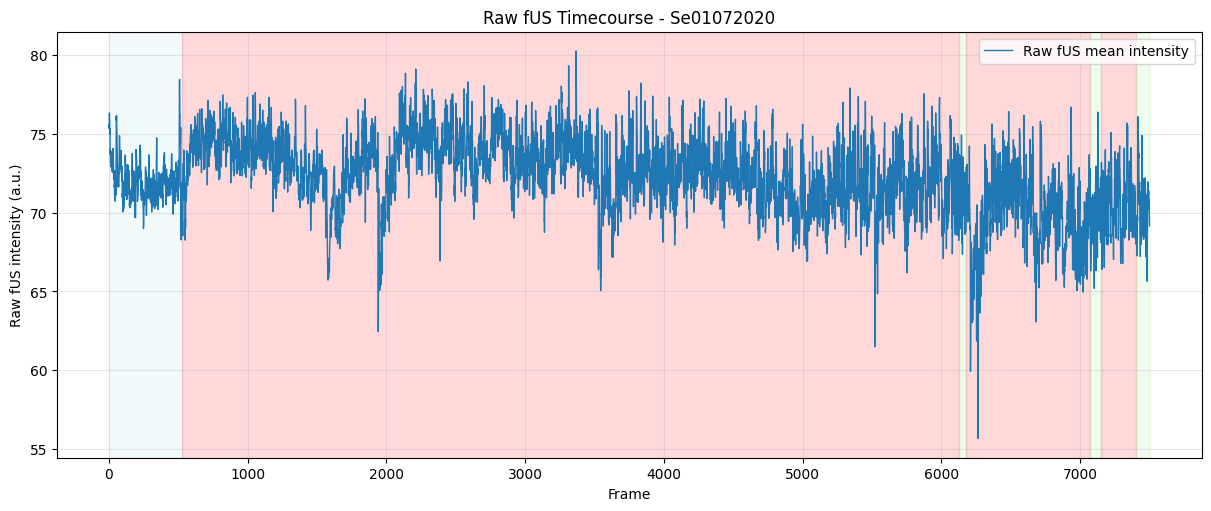

Subject: gus
  data_directory: c:\Users\ESPCI\Documents\GitHub\fUSPredict\sourcedata\gus
  data_output_dir: c:\Users\ESPCI\Documents\GitHub\fUSPredict\derivatives\preprocessing\gus
  - MISMATCH: Images=8000, Labels=9198. Shaving to 8000 frames.


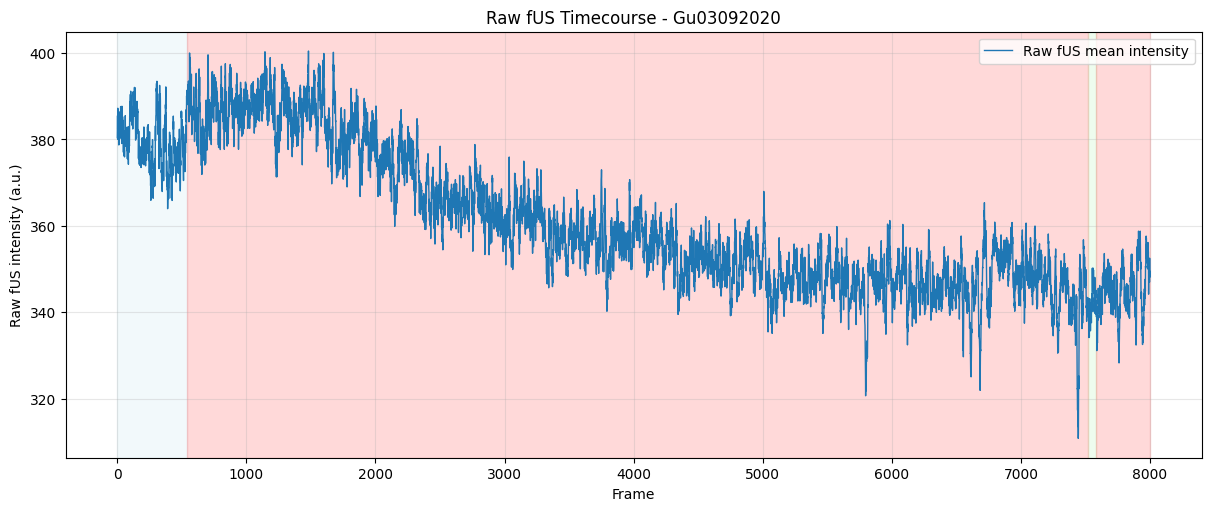

In [3]:
hf = importlib.reload(hf)

for subject in subjects:
    data_directory = source_root / subject
    data_output_dir = deriv_root / subject
    data_output_dir.mkdir(parents=True, exist_ok=True)

    print(f"Subject: {subject}")
    print(f"  data_directory: {data_directory}")
    print(f"  data_output_dir: {data_output_dir}")

    hf.plot_fus_timecourse_with_labels(str(data_directory), sessions="first")

---
## Stage 1: baseline_extracted (extract + save + sanity check)

In [ ]:
for subject in subjects:
    data_directory = source_root / subject
    baseline_output_dir = deriv_root / subject / "baseline_only"
    baseline_output_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n[{subject}] baseline extraction -> {baseline_output_dir}")

    baseline_npz_paths = process_all_baseline_files(
        data_directory=str(data_directory),
        output_dir=str(baseline_output_dir),
        overwrite=OVERWRITE_BASELINE,
        apply_log10=APPLY_LOG10,
        log10_eps=LOG10_EPS,
    )

    print(f"Saved/registered {len(baseline_npz_paths)} baseline files")

    sessions = load_all_baseline(str(baseline_output_dir))
    print(f"Loaded {len(sessions)} sessions")

    summary_df = summarize_npz_collection(baseline_npz_paths)
    display(summary_df)

    if sessions:
        s0 = sessions[0]
        frames0 = s0["frames"]
        print(f"First session_id: {s0['session_id']}")
        print(f"Frames shape: {frames0.shape}, dtype: {frames0.dtype}")
        print(f"Stage: {s0['metadata'].get('stage')}")
        print(f"did_log10: {s0['metadata'].get('did_log10')} | log10_eps: {s0['metadata'].get('log10_eps')}")


[secundo] baseline extraction -> c:\Users\ESPCI\Documents\GitHub\fUSPredict\derivatives\preprocessing\secundo\baseline_only
Found 34 fUS files to process
Skipping Se01072020 (already exists): baseline_Se01072020_baseline_extracted.npz
Skipping Se01092020 (already exists): baseline_Se01092020_baseline_extracted.npz
Skipping Se01102020 (already exists): baseline_Se01102020_baseline_extracted.npz
Skipping Se01122020 (already exists): baseline_Se01122020_baseline_extracted.npz
Skipping Se02122020 (already exists): baseline_Se02122020_baseline_extracted.npz
Skipping Se03022020 (already exists): baseline_Se03022020_baseline_extracted.npz
Skipping Se03092020 (already exists): baseline_Se03092020_baseline_extracted.npz
Skipping Se04022020 (already exists): baseline_Se04022020_baseline_extracted.npz
Skipping Se04032020 (already exists): baseline_Se04032020_baseline_extracted.npz
Skipping Se04062021 (already exists): baseline_Se04062021_baseline_extracted.npz
Skipping Se04082020 (already exists

,path,filename,exists,error,T,H,W,dtype,schema_version,session_id,...,target_size,did_highpass,highpass_params,did_pca,pca_params,did_clip,clip_bottom,clip_top,roi_mode,standardize_method
0,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Se01072020_baseline_extracted.npz,True,,526,128,101,float32,1,Se01072020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
1,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Se01092020_baseline_extracted.npz,True,,536,128,112,float32,1,Se01092020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
2,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Se01102020_baseline_extracted.npz,True,,502,128,122,float32,1,Se01102020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
3,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Se01122020_baseline_extracted.npz,True,,538,128,122,float32,1,Se01122020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
4,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Se02122020_baseline_extracted.npz,True,,537,128,122,float32,1,Se02122020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
5,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Se03022020_baseline_extracted.npz,True,,240,128,112,float32,1,Se03022020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
6,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Se03092020_baseline_extracted.npz,True,,518,128,112,float32,1,Se03092020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
7,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Se04022020_baseline_extracted.npz,True,,268,128,112,float32,1,Se04022020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
8,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Se04032020_baseline_extracted.npz,True,,906,128,91,float32,1,Se04032020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
9,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Se04062021_baseline_extracted.npz,True,,252,128,101,float32,1,Se04062021,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,


First session_id: Se01072020
Frames shape: (526, 128, 101), dtype: float32
Stage: baseline_extracted
did_log10: True | log10_eps: 9.999999974752427e-07

[gus] baseline extraction -> c:\Users\ESPCI\Documents\GitHub\fUSPredict\derivatives\preprocessing\gus\baseline_only
Found 13 fUS files to process
Skipping Gu03092020 (already exists): baseline_Gu03092020_baseline_extracted.npz
Skipping Gu05082020 (already exists): baseline_Gu05082020_baseline_extracted.npz
Skipping Gu06102020 (already exists): baseline_Gu06102020_baseline_extracted.npz
Skipping Gu11082020 (already exists): baseline_Gu11082020_baseline_extracted.npz
Skipping Gu12042021 (already exists): baseline_Gu12042021_baseline_extracted.npz
Skipping Gu12082020 (already exists): baseline_Gu12082020_baseline_extracted.npz
Skipping Gu17092020 (already exists): baseline_Gu17092020_baseline_extracted.npz
Skipping Gu20072020 (already exists): baseline_Gu20072020_baseline_extracted.npz
Skipping Gu23072020 (already exists): baseline_Gu2307

,path,filename,exists,error,T,H,W,dtype,schema_version,session_id,...,target_size,did_highpass,highpass_params,did_pca,pca_params,did_clip,clip_bottom,clip_top,roi_mode,standardize_method
0,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Gu03092020_baseline_extracted.npz,True,,539,128,112,float32,1,Gu03092020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
1,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Gu05082020_baseline_extracted.npz,True,,534,128,112,float32,1,Gu05082020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
2,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Gu06102020_baseline_extracted.npz,True,,549,128,81,float32,1,Gu06102020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
3,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Gu11082020_baseline_extracted.npz,True,,507,128,112,float32,1,Gu11082020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
4,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Gu12042021_baseline_extracted.npz,True,,268,128,101,float32,1,Gu12042021,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
5,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Gu12082020_baseline_extracted.npz,True,,516,128,112,float32,1,Gu12082020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
6,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Gu17092020_baseline_extracted.npz,True,,537,128,96,float32,1,Gu17092020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
7,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Gu20072020_baseline_extracted.npz,True,,539,128,112,float32,1,Gu20072020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
8,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Gu23072020_baseline_extracted.npz,True,,530,128,122,float32,1,Gu23072020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,
9,c:\Users\ESPCI\Documents\GitHub\fUSPredict\der...,baseline_Gu27082020_baseline_extracted.npz,True,,528,128,112,float32,1,Gu27082020,...,NaN,NaN,,NaN,,NaN,NaN,NaN,False,


First session_id: Gu03092020
Frames shape: (539, 128, 112), dtype: float32
Stage: baseline_extracted
did_log10: True | log10_eps: 9.999999974752427e-07


---
### Load Baseline Data

Load baseline sessions for model training.

In [5]:
# for subject in subjects:
#     baseline_output_dir = deriv_root / subject / "baseline_only"
#     baseline_sessions = load_all_baseline(str(baseline_output_dir))

#     if len(baseline_sessions) == 0:
#         print(f"\n[{subject}] No baseline sessions found")
#         continue

#     all_npz_paths = sorted(str(p) for p in baseline_output_dir.glob("baseline_*.npz"))
#     summary_df = summarize_npz_collection(all_npz_paths)

#     print(f"\nBaseline Data Summary: {subject}")
#     print(f"  Total sessions: {len(baseline_sessions)}")
#     total_frames = sum(s["frames"].shape[0] for s in baseline_sessions)
#     print(f"  Total baseline frames: {total_frames:,}")

#     spatial_shapes = [s["frames"].shape[1:] for s in baseline_sessions]
#     print(f"  Spatial dimensions: {set(spatial_shapes)}")

#     frame_counts = [s["frames"].shape[0] for s in baseline_sessions]
#     print(
#         f"  Frames per session: min={min(frame_counts)}, max={max(frame_counts)}, "
#         f"mean={np.mean(frame_counts):.0f}, std={np.std(frame_counts):.0f}"
#     )

#     first_session = baseline_sessions[0]
#     print(f"\n  First session ({first_session['session_id']}):")
#     print(f"    Frames: {first_session['frames'].shape[0]}")
#     print(f"    Shape: {first_session['frames'].shape}")
#     print(f"    Dtype: {first_session['frames'].dtype}")
#     print(
#         f"    Value range: [{first_session['frames'].min():.2f}, {first_session['frames'].max():.2f}]"
#     )

#     print("\n  Stage summary:")
#     display(summary_df[["filename", "session_id", "stage", "schema_version", "did_log10", "log10_eps", "error"]])

---
## Stage 2: Reorient & Resize


[secundo] geometry stage | inputs=34
  - Canonical outputs: 34


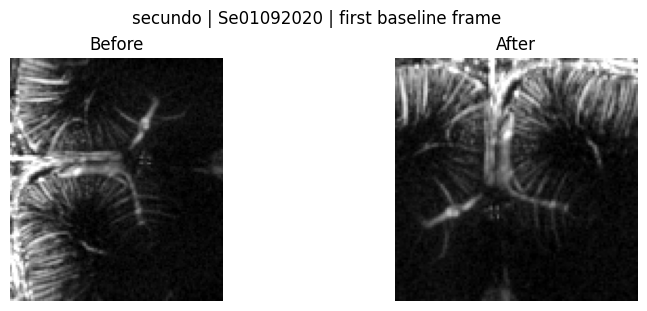

  [preview] saved secundo_Se01092020_before_after.png


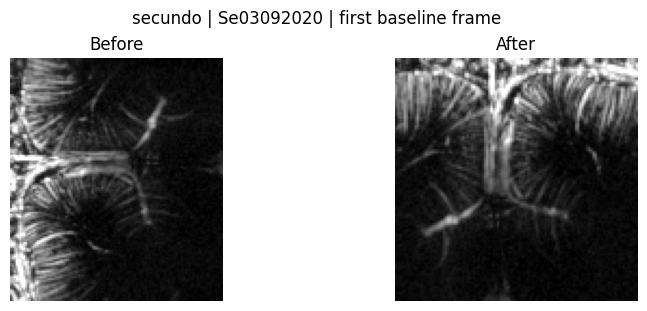

  [preview] saved secundo_Se03092020_before_after.png


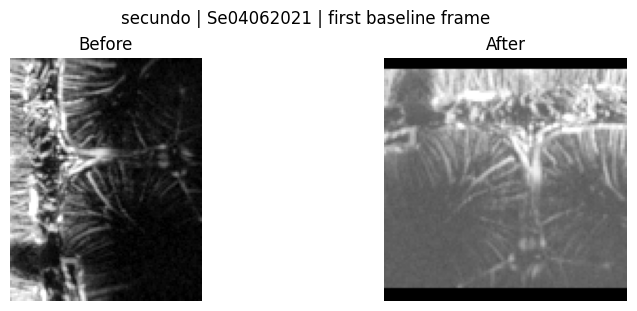

  [preview] saved secundo_Se04062021_before_after.png


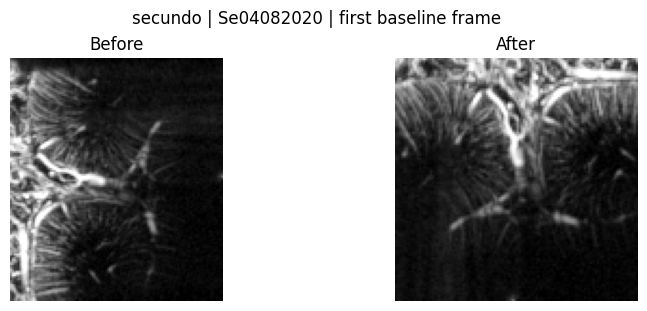

  [preview] saved secundo_Se04082020_before_after.png


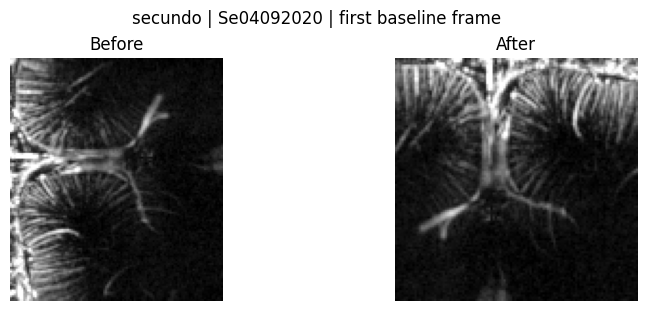

  [preview] saved secundo_Se04092020_before_after.png


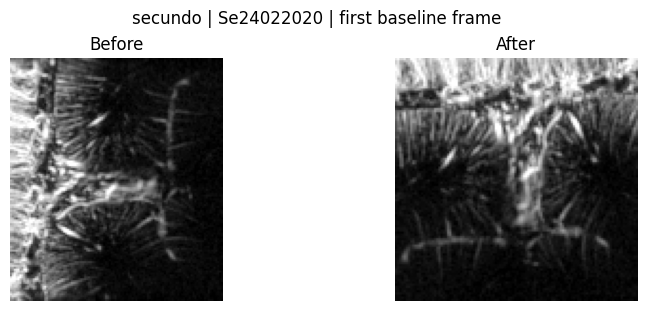

  [preview] saved secundo_Se24022020_before_after.png


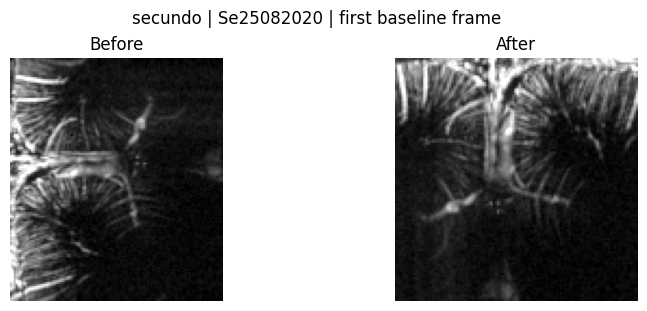

  [preview] saved secundo_Se25082020_before_after.png


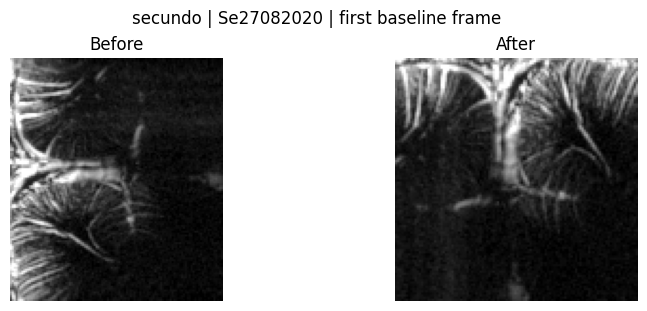

  [preview] saved secundo_Se27082020_before_after.png


,filename,session_id,stage,rotate_k,flip_lr,target_size,T,H,W,error
0,baseline_Se01072020_reoriented_resized.npz,Se01072020,reoriented_resized,-1,False,112,526,112,112,
1,baseline_Se01092020_reoriented_resized.npz,Se01092020,reoriented_resized,-1,True,112,536,112,112,
2,baseline_Se01102020_reoriented_resized.npz,Se01102020,reoriented_resized,-1,False,112,502,112,112,
3,baseline_Se01122020_reoriented_resized.npz,Se01122020,reoriented_resized,-1,False,112,538,112,112,
4,baseline_Se02122020_reoriented_resized.npz,Se02122020,reoriented_resized,-1,False,112,537,112,112,
5,baseline_Se03022020_reoriented_resized.npz,Se03022020,reoriented_resized,-1,False,112,240,112,112,
6,baseline_Se03092020_reoriented_resized.npz,Se03092020,reoriented_resized,-1,True,112,518,112,112,
7,baseline_Se04022020_reoriented_resized.npz,Se04022020,reoriented_resized,-1,False,112,268,112,112,
8,baseline_Se04032020_reoriented_resized.npz,Se04032020,reoriented_resized,-1,False,112,906,112,112,
9,baseline_Se04062021_reoriented_resized.npz,Se04062021,reoriented_resized,-1,False,112,252,112,112,



[gus] geometry stage | inputs=13
  - Canonical outputs: 13


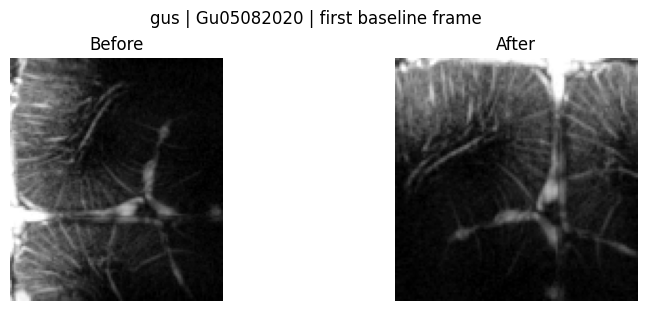

  [preview] saved gus_Gu05082020_before_after.png


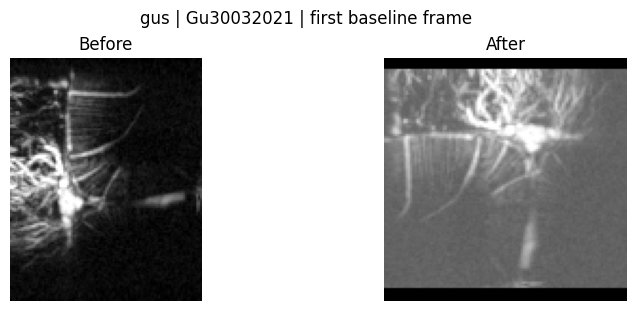

  [preview] saved gus_Gu30032021_before_after.png


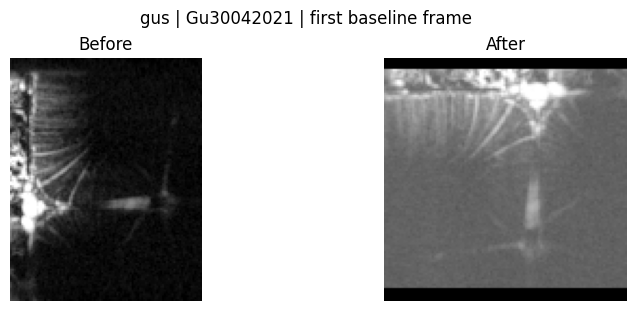

  [preview] saved gus_Gu30042021_before_after.png


,filename,session_id,stage,rotate_k,flip_lr,target_size,T,H,W,error
0,baseline_Gu03092020_reoriented_resized.npz,Gu03092020,reoriented_resized,-1,False,112,539,112,112,
1,baseline_Gu05082020_reoriented_resized.npz,Gu05082020,reoriented_resized,-1,True,112,534,112,112,
2,baseline_Gu06102020_reoriented_resized.npz,Gu06102020,reoriented_resized,-1,False,112,549,112,112,
3,baseline_Gu11082020_reoriented_resized.npz,Gu11082020,reoriented_resized,-1,False,112,507,112,112,
4,baseline_Gu12042021_reoriented_resized.npz,Gu12042021,reoriented_resized,-1,False,112,268,112,112,
5,baseline_Gu12082020_reoriented_resized.npz,Gu12082020,reoriented_resized,-1,False,112,516,112,112,
6,baseline_Gu17092020_reoriented_resized.npz,Gu17092020,reoriented_resized,-1,False,112,537,112,112,
7,baseline_Gu20072020_reoriented_resized.npz,Gu20072020,reoriented_resized,-1,False,112,539,112,112,
8,baseline_Gu23072020_reoriented_resized.npz,Gu23072020,reoriented_resized,-1,False,112,530,112,112,
9,baseline_Gu27082020_reoriented_resized.npz,Gu27082020,reoriented_resized,-1,False,112,528,112,112,


In [ ]:
# Session-specific left-right flips after rotation
FLIP_SESSION_IDS_BY_SUBJECT = {
    "secundo": {
        "Se04092020",
        "Se01092020",
        "Se25082020",
        "Se03092020",
        "Se27082020",
        "Se04062021",
        "Se04082020",
        "Se24022020",
    },
    "gus": {"Gu05082020", "Gu30032021", "Gu30042021"},
}

def _as_scalar_str(value):
    arr = np.asarray(value)
    if arr.size == 0:
        return ""
    item = arr.reshape(-1)[0].item() if arr.ndim > 0 else arr.item()
    if isinstance(item, bytes):
        return item.decode("utf-8")
    return str(item)


def _build_session_path_map(npz_paths):
    from utils.preprocessing.io import derive_session_id_from_path, load_stage_npz

    mapping = {}
    for path in npz_paths:
        try:
            _, meta = load_stage_npz(path)
            session_id = str(meta.get("session_id", "")).strip()
            if not session_id:
                session_id = derive_session_id_from_path(path)
            if session_id:
                mapping[session_id] = path
        except Exception:
            continue
    return mapping


def _compute_shared_preview_limits(reference_frame):
    arr = np.asarray(reference_frame, dtype=np.float32)
    finite = np.isfinite(arr)
    if not np.any(finite):
        return 0.0, 1.0

    valid = arr[finite]
    nonzero = valid[valid != 0]
    vals = nonzero if nonzero.size > 0 else valid

    lo, hi = np.percentile(vals, [1.0, 99.0])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo = float(np.nanmin(vals))
        hi = float(np.nanmax(vals))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return 0.0, 1.0
    return float(lo), float(hi)


def _prep_preview(frame, vmin, vmax):
    arr = np.asarray(frame, dtype=np.float32)
    finite = np.isfinite(arr)
    if not np.any(finite):
        return np.zeros_like(arr, dtype=np.float32)
    scaled = (arr - float(vmin)) / (float(vmax) - float(vmin) + 1e-8)
    return np.clip(scaled, 0.0, 1.0)


def _save_before_after_first_frame(before_frame, after_frame, subject, session_id, out_dir):
    vmin, vmax = _compute_shared_preview_limits(before_frame)
    fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
    axes[0].imshow(_prep_preview(before_frame, vmin=vmin, vmax=vmax), cmap="gray")
    axes[0].set_title("Before")
    axes[0].axis("off")
    axes[1].imshow(_prep_preview(after_frame, vmin=vmin, vmax=vmax), cmap="gray")
    axes[1].set_title("After")
    axes[1].axis("off")
    fig.suptitle(f"{subject} | {session_id} | first baseline frame")

    out_path = out_dir / f"{subject}_{session_id}_before_after.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"  [preview] saved {out_path.name}")


for subject in subjects:
    in_dir = deriv_root / subject / "baseline_only"
    out_dir = deriv_root / subject / "baseline_only_reoriented_resized"
    preview_dir = out_dir / "previews"
    flip_ids = set(FLIP_SESSION_IDS_BY_SUBJECT.get(subject, set()))

    in_paths = sorted(str(p) for p in in_dir.glob("baseline_*.npz"))
    print(f"\n[{subject}] geometry stage | inputs={len(in_paths)}")

    if len(in_paths) == 0:
        print(f"  - No baseline stage files found in {in_dir}")
        continue

    out_paths = reorient_baseline_sessions(
        in_npz_paths=in_paths,
        out_dir=str(out_dir),
        rotate_k=ROTATE_K,
        flip_session_ids=flip_ids,
        target_size=TARGET_SIZE,
        overwrite=OVERWRITE_GEOMETRY,
        save_previews=SAVE_GEOMETRY_PREVIEWS,
        preview_dir=str(preview_dir),
    )

    print(f"  - Canonical outputs: {len(out_paths)}")

    if SAVE_GEOMETRY_PREVIEWS and flip_ids:
        in_by_session = _build_session_path_map(in_paths)
        out_by_session = _build_session_path_map(out_paths)
        for session_id in sorted(flip_ids):
            in_path = in_by_session.get(session_id)
            out_path = out_by_session.get(session_id)
            if in_path is None or out_path is None:
                print(f"  [preview] skip {session_id}: missing input/output NPZ")
                continue

            with np.load(in_path, allow_pickle=True) as npz_in, np.load(out_path, allow_pickle=True) as npz_out:
                before = np.asarray(npz_in["frames"], dtype=np.float32)
                after = np.asarray(npz_out["frames"], dtype=np.float32)

            if before.ndim != 3 or after.ndim != 3 or before.shape[0] == 0 or after.shape[0] == 0:
                print(f"  [preview] skip {session_id}: invalid frame shape")
                continue

            _save_before_after_first_frame(
                before_frame=before[0],
                after_frame=after[0],
                subject=subject,
                session_id=session_id,
                out_dir=preview_dir,
            )

    summary_df = summarize_npz_collection(out_paths)
    show_cols = [
        "filename",
        "session_id",
        "stage",
        "rotate_k",
        "flip_lr",
        "target_size",
        "T",
        "H",
        "W",
        "error",
    ]
    show_cols = [c for c in show_cols if c in summary_df.columns]
    display(summary_df[show_cols])

---
## Stage 3: Filtering

In [11]:
for subject in subjects:
    in_dir = deriv_root / subject / "baseline_only_reoriented_resized"
    out_dir = deriv_root / subject / "baseline_only_filtered"

    in_paths = sorted(str(p) for p in in_dir.glob("baseline_*.npz"))
    print(f"\n[{subject}] filtering stage | inputs={len(in_paths)}")

    if len(in_paths) == 0:
        print(f"  - No reoriented stage files found in {in_dir}")
        continue

    print(
        f"  - options: highpass={ENABLE_HIGHPASS}, pca={ENABLE_PCA}, clip={ENABLE_CLIP}, "
        f"overwrite={OVERWRITE_FILTERING}"
    )

    out_paths = filter_reoriented_sessions(
        in_npz_paths=in_paths,
        out_dir=str(out_dir),
        enable_highpass=ENABLE_HIGHPASS,
        highpass_cutoff_hz=HIGHPASS_CUTOFF_HZ,
        highpass_order=HIGHPASS_ORDER,
        enable_pca=ENABLE_PCA,
        pca_var_keep=PCA_VAR_KEEP,
        pca_n_components=PCA_N_COMPONENTS,
        enable_clip=ENABLE_CLIP,
        clip_bottom=CLIP_BOTTOM,
        clip_top=CLIP_TOP,
        fps_fallback=FPS_FALLBACK,
        overwrite=OVERWRITE_FILTERING,
    )

    print(f"  - Canonical outputs: {len(out_paths)}")

    summary_df = summarize_npz_collection(out_paths)
    show_cols = [
        "filename",
        "session_id",
        "stage",
        "did_highpass",
        "highpass_params",
        "did_pca",
        "pca_params",
        "did_clip",
        "clip_bottom",
        "clip_top",
        "T",
        "H",
        "W",
        "error",
    ]
    show_cols = [c for c in show_cols if c in summary_df.columns]
    display(summary_df[show_cols])



[secundo] filtering stage | inputs=34
  - options: highpass=False, pca=False, clip=True, overwrite=False
  - Canonical outputs: 34


,filename,session_id,stage,did_highpass,highpass_params,did_pca,pca_params,did_clip,clip_bottom,clip_top,T,H,W,error
0,baseline_Se01072020_filtered.npz,Se01072020,filtered,False,,False,,True,1.0,99.0,526,112,112,
1,baseline_Se01092020_filtered.npz,Se01092020,filtered,False,,False,,True,1.0,99.0,536,112,112,
2,baseline_Se01102020_filtered.npz,Se01102020,filtered,False,,False,,True,1.0,99.0,502,112,112,
3,baseline_Se01122020_filtered.npz,Se01122020,filtered,False,,False,,True,1.0,99.0,538,112,112,
4,baseline_Se02122020_filtered.npz,Se02122020,filtered,False,,False,,True,1.0,99.0,537,112,112,
5,baseline_Se03022020_filtered.npz,Se03022020,filtered,False,,False,,True,1.0,99.0,240,112,112,
6,baseline_Se03092020_filtered.npz,Se03092020,filtered,False,,False,,True,1.0,99.0,518,112,112,
7,baseline_Se04022020_filtered.npz,Se04022020,filtered,False,,False,,True,1.0,99.0,268,112,112,
8,baseline_Se04032020_filtered.npz,Se04032020,filtered,False,,False,,True,1.0,99.0,906,112,112,
9,baseline_Se04062021_filtered.npz,Se04062021,filtered,False,,False,,True,1.0,99.0,252,112,112,



[gus] filtering stage | inputs=13
  - options: highpass=False, pca=False, clip=True, overwrite=False
  - Canonical outputs: 13


,filename,session_id,stage,did_highpass,highpass_params,did_pca,pca_params,did_clip,clip_bottom,clip_top,T,H,W,error
0,baseline_Gu03092020_filtered.npz,Gu03092020,filtered,False,,False,,True,1.0,99.0,539,112,112,
1,baseline_Gu05082020_filtered.npz,Gu05082020,filtered,False,,False,,True,1.0,99.0,534,112,112,
2,baseline_Gu06102020_filtered.npz,Gu06102020,filtered,False,,False,,True,1.0,99.0,549,112,112,
3,baseline_Gu11082020_filtered.npz,Gu11082020,filtered,False,,False,,True,1.0,99.0,507,112,112,
4,baseline_Gu12042021_filtered.npz,Gu12042021,filtered,False,,False,,True,1.0,99.0,268,112,112,
5,baseline_Gu12082020_filtered.npz,Gu12082020,filtered,False,,False,,True,1.0,99.0,516,112,112,
6,baseline_Gu17092020_filtered.npz,Gu17092020,filtered,False,,False,,True,1.0,99.0,537,112,112,
7,baseline_Gu20072020_filtered.npz,Gu20072020,filtered,False,,False,,True,1.0,99.0,539,112,112,
8,baseline_Gu23072020_filtered.npz,Gu23072020,filtered,False,,False,,True,1.0,99.0,530,112,112,
9,baseline_Gu27082020_filtered.npz,Gu27082020,filtered,False,,False,,True,1.0,99.0,528,112,112,


In [6]:
# Stage 4: Conjoined Video Preview (reoriented vs filtered)
from utils.preprocessing.io import derive_session_id_from_path, load_stage_npz
import inspect
hf = importlib.reload(hf)

HAS_PANEL_GAP = "panel_gap_px" in inspect.signature(hf.make_conjoined_video).parameters

MAKE_CONJOINED_VIDEOS = True
CONJOINED_MODE = "reoriented_vs_filtered"
CONJOINED_N_FRAMES = None
CONJOINED_SCALING_MODE = "shared_from_first"
CONJOINED_Q_LOW = 1.0
CONJOINED_Q_HIGH = 99.0
CONJOINED_SIGNED = [False, False]
CONJOINED_SIGNED_ABS_PERCENTILE = 97.0
CONJOINED_HEADER_HEIGHT = 28
CONJOINED_FONT_SCALE = 0.5
CONJOINED_BLUR_KSIZE = 0
CONJOINED_CODEC = "mp4v"
CONJOINED_PANEL_GAP_PX = 2
CONJOINED_FPS_FALLBACK = 10.0

def _build_session_path_map(npz_paths):
    mapping = {}
    for path in npz_paths:
        try:
            _, meta = load_stage_npz(str(path))
            session_id = str(meta.get("session_id", "")).strip()
            if not session_id:
                session_id = derive_session_id_from_path(str(path))
            if session_id:
                mapping[session_id] = str(path)
        except Exception as exc:
            print(f"  [viz] skip unreadable file {path}: {exc}")
    return mapping

def _fps_from_meta(meta):
    raw = meta.get("source_fps")
    try:
        val = float(np.asarray(raw).squeeze())
        if np.isfinite(val) and val > 0:
            return val
    except Exception:
        pass
    return None

if not MAKE_CONJOINED_VIDEOS:
    print("Conjoined video generation disabled (MAKE_CONJOINED_VIDEOS=False).")
else:
    if CONJOINED_MODE != "reoriented_vs_filtered":
        raise ValueError(
            f"Unsupported CONJOINED_MODE={CONJOINED_MODE!r}. Only 'reoriented_vs_filtered' is configured in this notebook."
        )

    for subject in subjects:
        before_dir = deriv_root / subject / "baseline_only_reoriented_resized"
        after_dir = deriv_root / subject / "baseline_only_filtered"

        before_paths = sorted(before_dir.glob("baseline_*.npz"))
        after_paths = sorted(after_dir.glob("baseline_*.npz"))

        print(f"\n[{subject}] conjoined video | before={len(before_paths)} after={len(after_paths)}")

        if len(before_paths) == 0 or len(after_paths) == 0:
            print("  - Skip: missing stage files (need both reoriented and filtered).")
            continue

        before_map = _build_session_path_map(before_paths)
        after_map = _build_session_path_map(after_paths)
        shared_session_ids = sorted(set(before_map.keys()) & set(after_map.keys()))

        if len(shared_session_ids) == 0:
            print("  - Skip: no shared session_id between stages.")
            continue

        session_id = shared_session_ids[0]
        before_path = before_map[session_id]
        after_path = after_map[session_id]

        try:
            before_frames, before_meta = load_stage_npz(before_path)
            after_frames, after_meta = load_stage_npz(after_path)
        except Exception as exc:
            print(f"  - Skip session={session_id}: failed to load stage files: {exc}")
            continue

        fps = _fps_from_meta(after_meta)
        if fps is None:
            fps = _fps_from_meta(before_meta)
        if fps is None:
            fps = float(CONJOINED_FPS_FALLBACK)

        out_dir = deriv_root / subject / "baseline_only_viz"
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / f"{subject}_{session_id}_reoriented_vs_filtered_conjoined.mp4"

        try:
            video_kwargs = dict(
                panels=[
                    np.asarray(before_frames, dtype=np.float32),
                    np.asarray(after_frames, dtype=np.float32),
                ],
                labels=["before", "filtered"],
                out_path=str(out_path),
                fps=float(fps),
                n_frames=CONJOINED_N_FRAMES,
                align_mode="trim",
                scaling_mode=CONJOINED_SCALING_MODE,
                q_low=CONJOINED_Q_LOW,
                q_high=CONJOINED_Q_HIGH,
                signed=list(CONJOINED_SIGNED),
                signed_abs_percentile=CONJOINED_SIGNED_ABS_PERCENTILE,
                header_height=CONJOINED_HEADER_HEIGHT,
                font_scale=CONJOINED_FONT_SCALE,
                blur_ksize=CONJOINED_BLUR_KSIZE,
                codec=CONJOINED_CODEC,
            )
            if HAS_PANEL_GAP:
                video_kwargs["panel_gap_px"] = CONJOINED_PANEL_GAP_PX
            summary = hf.make_conjoined_video(**video_kwargs)
            print(
                f"  - Saved conjoined video | session={session_id} | "
                f"fps={summary['fps']:.3f} | frames={summary['T_used']} -> {summary['out_path']}"
            )
        except Exception as exc:
            print(f"  - Failed to build conjoined video for session={session_id}: {exc}")



[secundo] conjoined video | before=34 after=34
  - Saved conjoined video | session=Se01072020 | fps=10.000 | frames=526 -> c:\Users\ESPCI\Documents\GitHub\fUSPredict\derivatives\preprocessing\secundo\baseline_only_viz\secundo_Se01072020_reoriented_vs_filtered_conjoined.mp4

[gus] conjoined video | before=13 after=13
  - Saved conjoined video | session=Gu03092020 | fps=10.000 | frames=539 -> c:\Users\ESPCI\Documents\GitHub\fUSPredict\derivatives\preprocessing\gus\baseline_only_viz\gus_Gu03092020_reoriented_vs_filtered_conjoined.mp4
